In [ ]:
# Imports
import os
import time
import random
import math
import json
from pathlib import Path
from typing import Dict, Any, Optional

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torch.cuda.amp import GradScaler, autocast

from torchvision import datasets, transforms, models

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [ ]:
# Device configuration
use_cuda = torch.cuda.is_available()
device = torch.device('cuda' if use_cuda else 'cpu')
if use_cuda:
    torch.backends.cudnn.benchmark = True
print('CUDA available:', use_cuda)
print('Device:', device)
print('GPU count:', torch.cuda.device_count())
if use_cuda:
    print('GPU name:', torch.cuda.get_device_name(0))

CUDA available: True
Device: cuda
GPU count: 1
GPU name: NVIDIA GeForce RTX 3060


In [ ]:
class CFG:
    data_dir = '/content/Resized_Dataset'
    disease_types = ['No Fibrosis','Portal Fibrosis','Periportal Fibrosis','Septal Fibrosis','Cirrhosis']
    image_size = 256
    batch_size = 32
    num_workers = 0
    epochs = 50
    lr = 1e-3
    weight_decay = 1e-4
    early_stop_patience = 8
    min_delta = 1e-4
    val_split = 0.15
    test_split = 0.15
    use_augment = False  # mirrors "without augmentation" benchmark
    checkpoint_path = 'best_model.pt'
    fp16 = True
    lambda_phys = 0.1  # weight for physics-informed loss

print('Classes:', CFG.disease_types)


Classes: ['No Fibrosis', 'Portal Fibrosis', 'Periportal Fibrosis', 'Septal Fibrosis', 'Cirrhosis']


In [ ]:
from pathlib import Path

rows = []
base = Path(CFG.data_dir)
for cls_id, cls in enumerate(CFG.disease_types):
    cls_dir = base/cls
    if not cls_dir.exists():
        continue
    for p in cls_dir.glob('*'):
        if p.suffix.lower() in {'.jpg','.jpeg','.png','.bmp','.tif','.tiff'}:
            rows.append({'File': f'{cls}/{p.name}', 'DiseaseID': cls_id, 'Disease Type': cls})

train_df = pd.DataFrame(rows)
print(train_df.head(3))
print('Total images:', len(train_df))


                    File  DiseaseID Disease Type
0  No Fibrosis/a6645.jpg          0  No Fibrosis
1    No Fibrosis/h39.jpg          0  No Fibrosis
2   No Fibrosis/a197.jpg          0  No Fibrosis
Total images: 6343


In [ ]:
import torch.multiprocessing as mp
mp.set_sharing_strategy("file_system")

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

base_transforms = [
    transforms.Resize((CFG.image_size, CFG.image_size)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
]

if CFG.use_augment:
    train_transforms = transforms.Compose([
        transforms.Resize((CFG.image_size, CFG.image_size)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=7),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ])
else:
    train_transforms = transforms.Compose(base_transforms)

val_test_transforms = transforms.Compose(base_transforms)

full_ds_plain = datasets.ImageFolder(root=CFG.data_dir)
class_to_idx = full_ds_plain.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

labels = np.array([full_ds_plain.samples[i][1] for i in range(len(full_ds_plain))])
indices = np.arange(len(full_ds_plain))

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=CFG.test_split, random_state=seed)
trainval_idx, test_idx = next(sss1.split(indices, labels))

labels_trainval = labels[trainval_idx]
indices_trainval = indices[trainval_idx]
val_size = CFG.val_split / (1.0 - CFG.test_split)
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_size, random_state=seed)
train_idx_rel, val_idx_rel = next(sss2.split(indices_trainval, labels_trainval))
train_idx = indices_trainval[train_idx_rel]
val_idx = indices_trainval[val_idx_rel]

print(f'Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}')

class ImageFolderWithTransform(datasets.ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root=root)
        self.transform = transform
    def __getitem__(self, index):
        path, target = self.samples[index]
        sample = self.loader(path)
        if self.transform is not None:
            sample = self.transform(sample)
        return sample, target

train_ds_full = ImageFolderWithTransform(root=CFG.data_dir, transform=train_transforms)
val_ds_full   = ImageFolderWithTransform(root=CFG.data_dir, transform=val_test_transforms)
test_ds_full  = ImageFolderWithTransform(root=CFG.data_dir, transform=val_test_transforms)

train_ds = Subset(train_ds_full, train_idx)
val_ds   = Subset(val_ds_full, val_idx)
test_ds  = Subset(test_ds_full, test_idx)

use_cuda = torch.cuda.is_available()
train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,  num_workers=CFG.num_workers, pin_memory=use_cuda)
val_loader   = DataLoader(val_ds,   batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers, pin_memory=use_cuda)
test_loader  = DataLoader(test_ds,  batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers, pin_memory=use_cuda)

xb, yb = next(iter(train_loader))
print('Batch images shape:', tuple(xb.shape))


Train: 4439, Val: 952, Test: 952
Batch images shape: (32, 3, 256, 256)


In [ ]:
class PhysicsInformedHead(nn.Module):
    def __init__(self, in_features: int, num_classes: int):
        super().__init__()
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, feats: torch.Tensor) -> torch.Tensor:
        logits = self.classifier(feats)
        return logits

    def physics_residual_from_feats(self, feats: torch.Tensor, logits: torch.Tensor) -> torch.Tensor:
      top = torch.logsumexp(logits, dim=1).sum()
      (g,) = torch.autograd.grad(top, feats, create_graph=True, retain_graph=True, allow_unused=False)
      return g.pow(2).mean()

class ResNet50PINN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        try:
            weights = models.ResNet50_Weights.IMAGENET1K_V2
        except Exception:
            weights = 'DEFAULT'
        backbone = models.resnet50(weights=weights)
        self.features = nn.Sequential(*(list(backbone.children())[:-1]))
        in_features = backbone.fc.in_features
        self.head = PhysicsInformedHead(in_features, num_classes)

    def forward(self, x: torch.Tensor):
        feats = self.features(x)
        feats = feats.flatten(1)
        logits = self.head(feats)
        return logits, feats

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ResNet50PINN(num_classes=len(CFG.disease_types)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)
scaler = GradScaler(enabled=CFG.fp16 and torch.cuda.is_available())

@torch.no_grad()
def accuracy(logits: torch.Tensor, targets: torch.Tensor) -> float:
    return (logits.argmax(1) == targets).float().mean().item()

print('Model with Physics-Informed head ready.')


Model with Physics-Informed head ready.


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    loss_sum = 0.0; acc_sum = 0.0; n = 0
    for imgs, lbls in loader:
        imgs = imgs.to(device, non_blocking=True)
        lbls = lbls.to(device, non_blocking=True)
        imgs.requires_grad_(True)

        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=scaler.is_enabled()):
            logits, feats = model(imgs)
            ce = criterion(logits, lbls)
            phys = model.head.physics_residual_from_feats(feats, logits)
            loss = ce + CFG.lambda_phys * phys
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = imgs.size(0)
        loss_sum += loss.item() * bs
        acc_sum += (logits.detach().argmax(1) == lbls).float().mean().item() * bs
        n += bs
    return loss_sum / n, acc_sum / n


def validate(model, loader, criterion, device):
    model.eval()
    loss_sum = 0.0; acc_sum = 0.0; n = 0
    for imgs, lbls in loader:
        imgs = imgs.to(device, non_blocking=True)
        lbls = lbls.to(device, non_blocking=True)
        # For inputs-based:
        imgs.requires_grad_(True)
        logits, feats = model(imgs)
        ce = criterion(logits, lbls)
        phys = model.head.physics_residual_from_feats(feats, logits)
        loss = ce + CFG.lambda_phys * phys

        bs = imgs.size(0)
        loss_sum += loss.item() * bs
        acc_sum += (logits.argmax(1) == lbls).float().mean().item() * bs
        n += bs
    return loss_sum / n, acc_sum / n

best_val_loss = float('inf')
best_epoch = -1
no_improve = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, CFG.epochs + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
    va_loss, va_acc = validate(model, val_loader, criterion, device)

    scheduler.step(va_loss)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)

    improved = (best_val_loss - va_loss) > CFG.min_delta
    if improved:
        best_val_loss = va_loss
        best_epoch = epoch
        no_improve = 0
        torch.save({'model_state': model.state_dict(),
                    'optimizer_state': optimizer.state_dict(),
                    'epoch': epoch,
                    'best_val_loss': best_val_loss,
                    'class_to_idx': class_to_idx}, CFG.checkpoint_path)
    else:
        no_improve += 1

    print(f"Epoch {epoch:03d}/{CFG.epochs} | train_loss={tr_loss:.4f}, train_acc={tr_acc:.4f} | val_loss={va_loss:.4f}, val_acc={va_acc:.4f} | time={(time.time()-t0):.1f}s | best_epoch={best_epoch}")

    if no_improve >= CFG.early_stop_patience:
        print(f"Early stopping at epoch {epoch}, best epoch was {best_epoch} with val_loss={best_val_loss:.4f}")
        break

import os
if os.path.exists(CFG.checkpoint_path):
    ckpt = torch.load(CFG.checkpoint_path, map_location=torch.device('cpu'))
    model.load_state_dict(ckpt['model_state'])
    print('Loaded best model from', CFG.checkpoint_path)

Epoch 001/50 | train_loss=0.7588, train_acc=0.6736 | val_loss=0.8522, val_acc=0.6586 | time=31.8s | best_epoch=1
Epoch 002/50 | train_loss=0.4774, train_acc=0.8011 | val_loss=1.2020, val_acc=0.5599 | time=26.0s | best_epoch=1
Epoch 003/50 | train_loss=0.3011, train_acc=0.8829 | val_loss=1.1339, val_acc=0.7279 | time=25.8s | best_epoch=1
Epoch 004/50 | train_loss=0.2473, train_acc=0.9173 | val_loss=0.5240, val_acc=0.8277 | time=26.6s | best_epoch=4
Epoch 005/50 | train_loss=0.1222, train_acc=0.9579 | val_loss=1.3415, val_acc=0.7532 | time=26.5s | best_epoch=4
Epoch 006/50 | train_loss=0.0883, train_acc=0.9680 | val_loss=1.2093, val_acc=0.6471 | time=26.7s | best_epoch=4
Epoch 007/50 | train_loss=0.1225, train_acc=0.9567 | val_loss=0.3858, val_acc=0.8992 | time=27.2s | best_epoch=7
Epoch 008/50 | train_loss=0.0709, train_acc=0.9777 | val_loss=0.1472, val_acc=0.9580 | time=27.0s | best_epoch=8
Epoch 009/50 | train_loss=0.0281, train_acc=0.9921 | val_loss=0.1430, val_acc=0.9580 | time=27.2

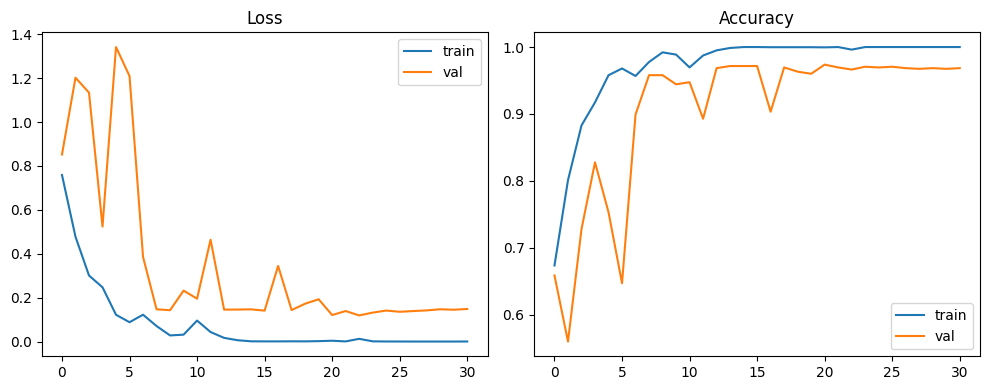

In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.title('Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history['train_acc'], label='train')
plt.plot(history['val_acc'], label='val')
plt.title('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

Classification report:
                     precision    recall  f1-score   support

          Cirrhosis       0.98      0.99      0.98       255
        No Fibrosis       1.00      1.00      1.00       320
Periportal Fibrosis       0.93      0.89      0.91       119
    Portal Fibrosis       0.96      0.91      0.94       129
    Septal Fibrosis       0.93      0.98      0.96       129

           accuracy                           0.97       952
          macro avg       0.96      0.96      0.96       952
       weighted avg       0.97      0.97      0.97       952



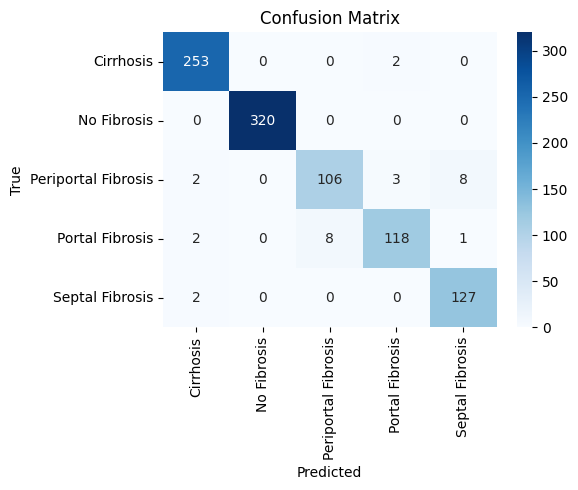

In [ ]:
model.eval()
all_targets, all_preds = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device, non_blocking=True)
        lbls = lbls.to(device, non_blocking=True)
        logits, feats = model(imgs)
        preds = logits.argmax(1)
        all_targets.extend(lbls.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())

print('Classification report:')
print(classification_report(all_targets, all_preds, target_names=[idx_to_class[i] for i in range(len(idx_to_class))]))

cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[idx_to_class[i] for i in range(len(idx_to_class))],
            yticklabels=[idx_to_class[i] for i in range(len(idx_to_class))])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image

def predict_image(path: str):
    img = Image.open(path).convert('L')
    img = transforms.functional.resize(img, (CFG.image_size, CFG.image_size))
    img = transforms.functional.to_tensor(img)
    img = img.repeat(3, 1, 1)
    img = transforms.functional.normalize(img, [0.485,0.456,0.406], [0.229,0.224,0.225])
    img = img.unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        logits, feats = model(img)
        prob = torch.softmax(logits, dim=1)
        conf, pred = prob.max(dim=1)
    return idx_to_class[pred.item()], float(conf.item())

pred, conf = predict_image('/content/Resized_Dataset/No Fibrosis/a197.jpg')
print(pred, conf)

No Fibrosis 0.9999359846115112
